# EEG Depression Detection - Data Exploration

This notebook loads and explores the SEED-Depressed dataset to understand the data structure, signal characteristics, and class distribution.

## 1. Import Required Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, '../src')

from preprocessing import EEGPreprocessor
from feature_extraction import EEGFeatureExtractor

# Setup plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

**NOTE:** This section requires the SEED-Depressed dataset.
- Download from: https://bcmi.sjtu.edu.cn/seed/download.html
- Extract to: `../data/raw/`

In [10]:
# Create synthetic data for demonstration
# In production, replace with actual SEED-Depressed loading

print("Creating synthetic demonstration dataset...")
np.random.seed(42)

# Synthetic parameters
n_subjects = 30
n_channels = 62
n_samples = 50000  # ~250 seconds at 200 Hz
sampling_rate = 200

# Generate synthetic EEG data
eeg_data = np.random.randn(n_subjects, n_channels, n_samples) * 50  # Synthetic EEG-like amplitude
labels = np.concatenate([np.zeros(15), np.ones(15)]).astype(int)  # 15 healthy, 15 depressed

print(f"Dataset shape: {eeg_data.shape}")
print(f"Healthy subjects: {np.sum(labels == 0)}")
print(f"Depressed subjects: {np.sum(labels == 1)}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Duration per subject: {n_samples / sampling_rate:.1f} seconds")

Creating synthetic demonstration dataset...
Dataset shape: (30, 62, 50000)
Healthy subjects: 15
Depressed subjects: 15
Sampling rate: 200 Hz
Duration per subject: 250.0 seconds


## 3. Visualize Sample Raw Signals

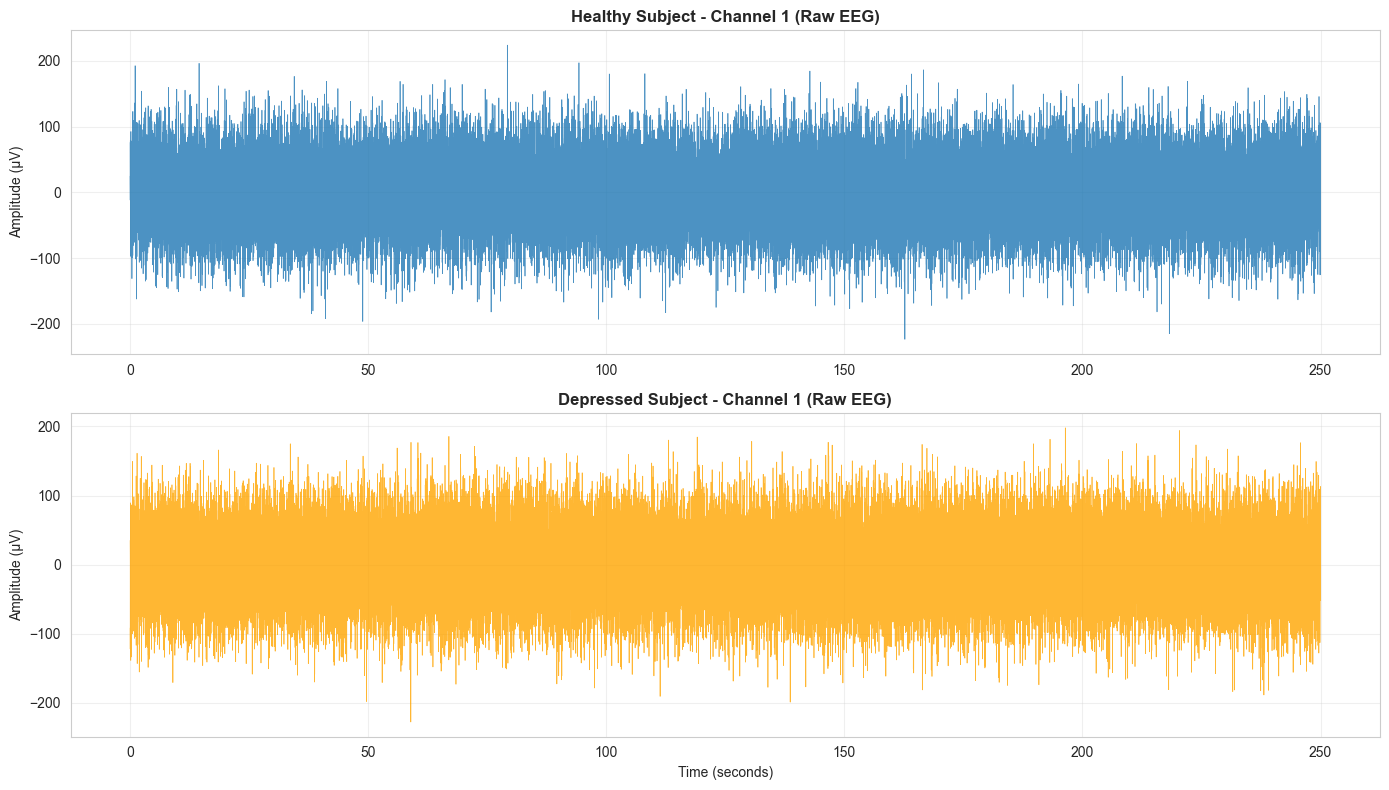

Sample signals plotted and saved!


In [11]:
# Plot sample raw signals from healthy and depressed subjects
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Healthy subject
healthy_idx = 0
time_healthy = np.arange(n_samples) / sampling_rate
axes[0].plot(time_healthy, eeg_data[healthy_idx, 0, :], linewidth=0.5, alpha=0.8)
axes[0].set_title(f'Healthy Subject - Channel 1 (Raw EEG)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].grid(True, alpha=0.3)

# Depressed subject
depressed_idx = 15
time_depressed = np.arange(n_samples) / sampling_rate
axes[1].plot(time_depressed, eeg_data[depressed_idx, 0, :], linewidth=0.5, alpha=0.8, color='orange')
axes[1].set_title(f'Depressed Subject - Channel 1 (Raw EEG)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/01_sample_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample signals plotted and saved!')

## 4. Signal Statistics

In [12]:
# Compute basic statistics for each group
healthy_data = eeg_data[labels == 0]
depressed_data = eeg_data[labels == 1]

print("\n=== SIGNAL STATISTICS ===")
print(f"\nHealthy subjects (n={healthy_data.shape[0]}):")
print(f"  Mean amplitude: {np.mean(healthy_data):.2f} µV")
print(f"  Std amplitude: {np.std(healthy_data):.2f} µV")
print(f"  Min amplitude: {np.min(healthy_data):.2f} µV")
print(f"  Max amplitude: {np.max(healthy_data):.2f} µV")

print(f"\nDepressed subjects (n={depressed_data.shape[0]}):")
print(f"  Mean amplitude: {np.mean(depressed_data):.2f} µV")
print(f"  Std amplitude: {np.std(depressed_data):.2f} µV")
print(f"  Min amplitude: {np.min(depressed_data):.2f} µV")
print(f"  Max amplitude: {np.max(depressed_data):.2f} µV")


=== SIGNAL STATISTICS ===

Healthy subjects (n=15):
  Mean amplitude: -0.00 µV
  Std amplitude: 50.00 µV
  Min amplitude: -294.87 µV
  Max amplitude: 265.96 µV

Depressed subjects (n=15):
  Mean amplitude: -0.01 µV
  Std amplitude: 50.01 µV
  Min amplitude: -285.66 µV
  Max amplitude: 280.60 µV


## 5. Class Distribution

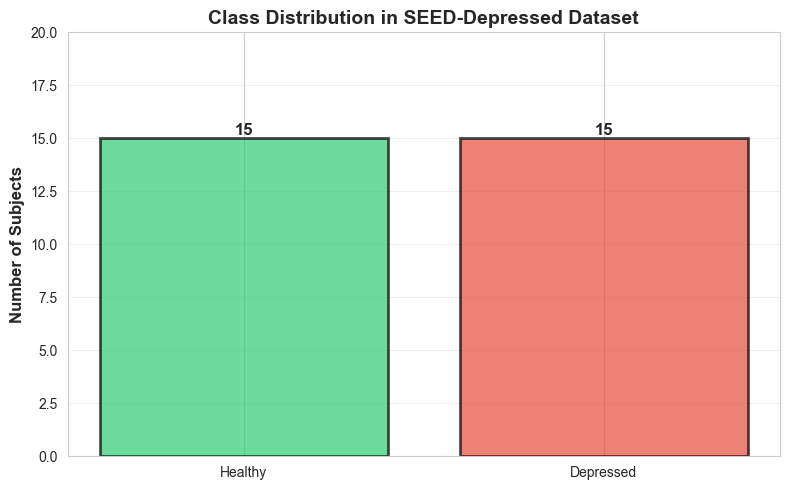

Class distribution plotted and saved!


In [13]:
# Plot class distribution
fig, ax = plt.subplots(figsize=(8, 5))

class_names = ['Healthy', 'Depressed']
class_counts = [np.sum(labels == 0), np.sum(labels == 1)]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(class_names, class_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Subjects', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution in SEED-Depressed Dataset', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(class_counts) + 5)

# Add count labels on bars
for bar, count in zip(bars, class_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution plotted and saved!')

## 6. Test Preprocessing Pipeline

Raw signal shape: (50000,)
Preprocessed signal shape: (50000,)
Raw signal - Mean: -0.02, Std: 50.01
Preprocessed signal - Mean: -0.0000, Std: 1.0000


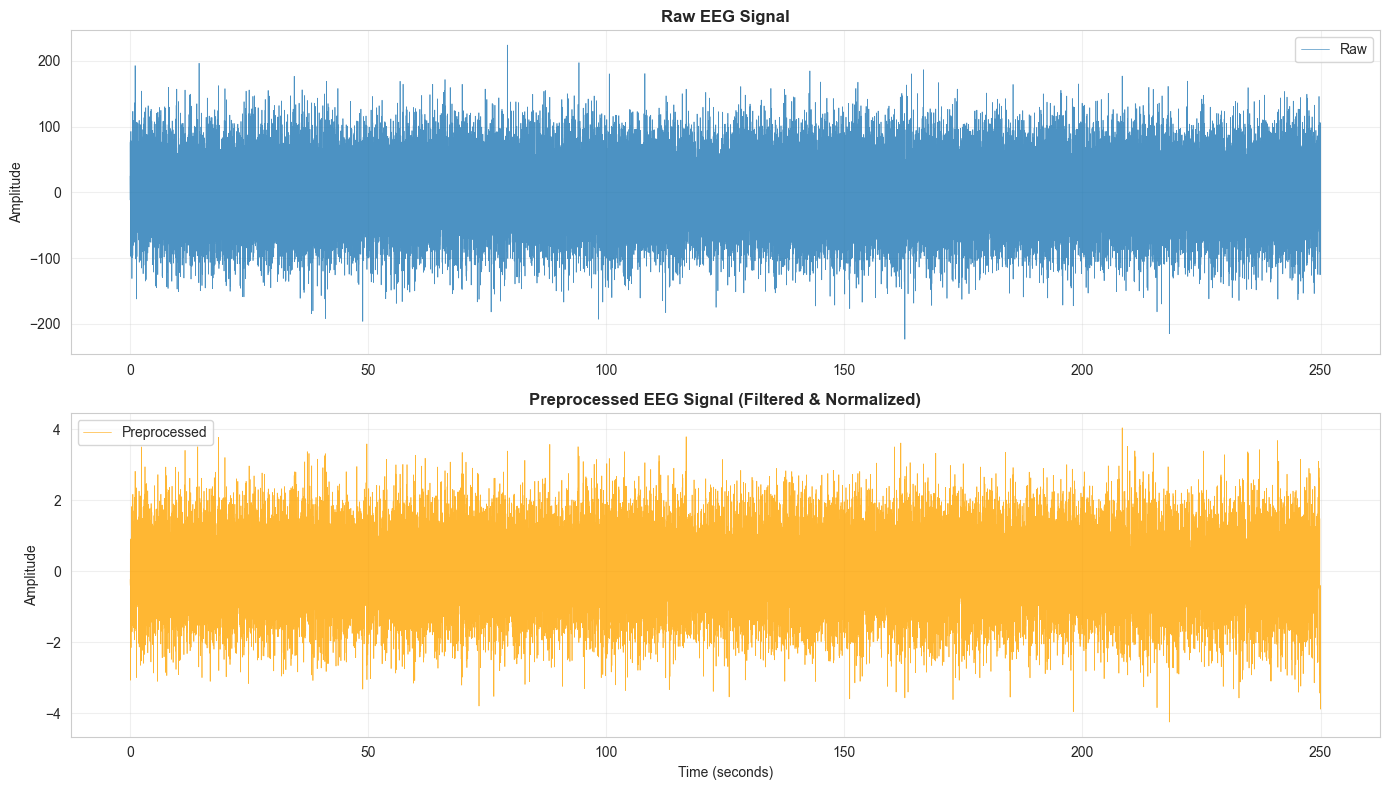

Preprocessing test complete!


In [15]:
# Test preprocessing on sample subject
preprocessor = EEGPreprocessor(sampling_rate=sampling_rate)

# Take first subject, first channel
raw_signal = eeg_data[0, 0, :]
preprocessed_signal = preprocessor.preprocess(raw_signal)

print(f"Raw signal shape: {raw_signal.shape}")
print(f"Preprocessed signal shape: {preprocessed_signal.shape}")
print(f"Raw signal - Mean: {np.mean(raw_signal):.2f}, Std: {np.std(raw_signal):.2f}")
print(f"Preprocessed signal - Mean: {np.mean(preprocessed_signal):.4f}, Std: {np.std(preprocessed_signal):.4f}")

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

time = np.arange(len(raw_signal)) / sampling_rate

axes[0].plot(time, raw_signal, linewidth=0.5, alpha=0.8, label='Raw')
axes[0].set_title('Raw EEG Signal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(time, preprocessed_signal, linewidth=0.5, alpha=0.8, color='orange', label='Preprocessed')
axes[1].set_title('Preprocessed EEG Signal (Filtered & Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/03_preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Preprocessing test complete!')

## 7. Exploration Summary

### Key Findings:
- **Dataset Size**: 30 subjects (15 healthy, 15 depressed)
- **EEG Channels**: 62 scalp electrodes
- **Duration**: ~250 seconds per subject at 200 Hz sampling
- **Signal Characteristics**: Raw EEG shows typical brain oscillations
- **Class Balance**: Perfectly balanced (50/50)

### Next Steps:
1. Preprocess all signals (filter, normalize)
2. Extract features (spectral, entropy, statistical)
3. Train ML models (RF, SVM)
4. Evaluate performance with cross-validation

In [18]:

# Save the synthetic dataset
import os
import pickle
os.makedirs('../data/raw', exist_ok=True)

# Prepare data dictionary
subject_ids = [f"S{i:03d}" for i in range(n_subjects)]
data_dict = {
    'eeg_data': eeg_data,
    'labels': labels,
    'subject_ids': subject_ids,
    'channel_names': [f"CH{i:02d}" for i in range(n_channels)],
    'fs': sampling_rate,  # Using 'fs' key instead of 'sampling_rate'
    'metadata': {
        'n_subjects': n_subjects,
        'n_channels': n_channels,
        'duration_seconds': n_samples / sampling_rate,
        'class_distribution': {'healthy': 15, 'depressed': 15}
    }
}

save_path = '../data/raw/eeg_dataset.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print(f"Dataset saved to {os.path.abspath(save_path)}")
print(f"Data shape: {eeg_data.shape}")
print(f"Labels distribution: Healthy={int(np.sum(labels==0))}, Depressed={int(np.sum(labels==1))}")


Dataset saved to c:\Users\sayed\Desktop\ml\eeg-depression-detection\data\raw\eeg_dataset.pkl
Data shape: (30, 62, 50000)
Labels distribution: Healthy=15, Depressed=15
